# Figuras para la memoria: construcción del datacubo

Este cuaderno genera figuras reproducibles a partir del datacubo definitivo de Galicia. Usa una
rejilla de 1 km × 1 km, el periodo completo que contiene el fichero NetCDF y el target oficial
EGIF. Las cifras se calculan durante la ejecución, para que no queden desactualizadas si se
reconstruye el producto.

Las figuras se muestran con fondo blanco. Para guardarlas a 300 dpi, añade
`fig.savefig(..., dpi=300, bbox_inches='tight')` antes de cada `plt.show()`.


In [13]:
from pathlib import Path
import json
import os
import sys

# Corrige la localización de GDAL en kernels Conda de Windows antes de cargar GeoPandas.
gdal_data = Path(sys.prefix) / 'Library' / 'share' / 'gdal'
if gdal_data.is_dir():
    os.environ.setdefault('GDAL_DATA', str(gdal_data))

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import xarray as xr

def find_project_root(start: Path) -> Path:
    """Localiza la raíz del repositorio aunque PyCharm ejecute desde notebooks/."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError(
        'No se ha localizado la raíz del proyecto. Abre el notebook dentro del repositorio.'
    )

ROOT = find_project_root(Path.cwd())

CUBE_PATH = ROOT / 'data/processed/datacube/galicia_1km.nc'
GRID_PATH = ROOT / 'data/processed/grid/galicia_grid_1km.gpkg'
BOUNDARY_PATH = ROOT / 'data/raw/igm/galicia_boundary.geojson'
METADATA_PATH = ROOT / 'data/processed/tabular/egif/metadata.json'

assert CUBE_PATH.exists(), f'No se encuentra {CUBE_PATH}'
assert GRID_PATH.exists(), f'No se encuentra {GRID_PATH}'

cube = xr.open_dataset(CUBE_PATH)
grid = gpd.read_file(GRID_PATH)
boundary = gpd.read_file(BOUNDARY_PATH).to_crs(grid.crs)
metadata = json.loads(METADATA_PATH.read_text(encoding='utf-8'))

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'font.size': 10, 'axes.titleweight': 'bold', 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.dpi': 120,
})

extent = (float(cube.x.min()) - 500, float(cube.x.max()) + 500,
          float(cube.y.min()) - 500, float(cube.y.max()) + 500)
active = cube['is_galicia'].values.astype(bool)

def draw_boundary(ax, color='#202020', linewidth=.65):
    """Dibuja el límite sin depender del backend gráfico de GeoPandas."""
    geometry = boundary.geometry.union_all()
    polygons = geometry.geoms if geometry.geom_type == 'MultiPolygon' else [geometry]
    for polygon in polygons:
        x_coords, y_coords = polygon.exterior.xy
        ax.plot(x_coords, y_coords, color=color, linewidth=linewidth)

def map_layer(ax, values, title, cmap='viridis', unit='', vmin=None, vmax=None):
    """Dibuja una capa xarray (y, x) sobre la misma referencia cartográfica."""
    layer = np.ma.masked_where(~active | ~np.isfinite(values), values)
    image = ax.imshow(layer, origin='lower', extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
    draw_boundary(ax, color='#202020', linewidth=.65)
    ax.set(title=title, xlabel='x (m, EPSG:3035)', ylabel='y (m, EPSG:3035)')
    ax.set_aspect('equal')
    colorbar = plt.colorbar(image, ax=ax, shrink=.78, pad=.02)
    if unit:
        colorbar.set_label(unit)
    return image


## 1. Dominio espacial: rectángulo regular y máscara de Galicia

El NetCDF conserva el rectángulo completo porque permite almacenar capas homogéneas `(y, x)` y
`(time, y, x)`. La máscara `is_galicia` identifica las celdas modelables; al exportar a Parquet
solo se conservan las celdas activas. Esta figura explica por qué el cubo y la tabla no tienen la
misma forma.


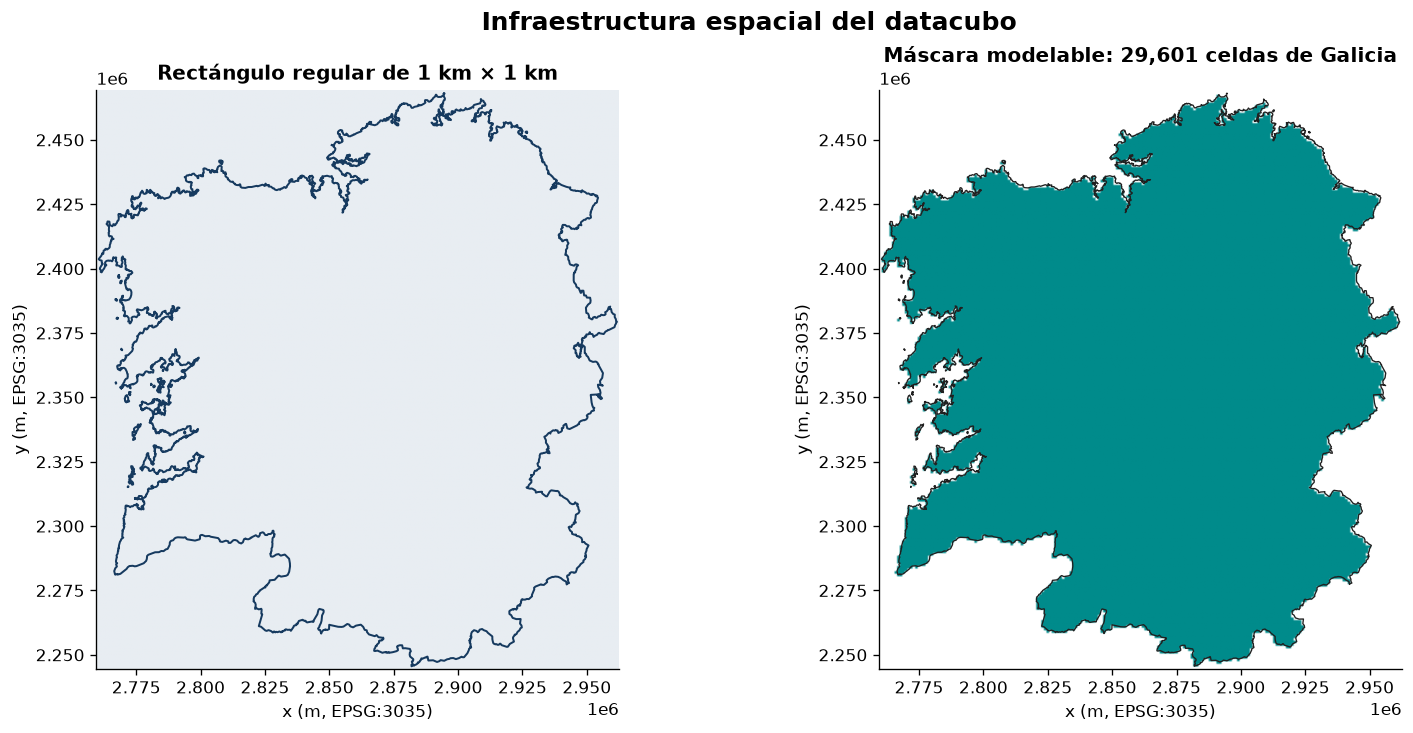

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)

axes[0].imshow(np.ones_like(active), origin='lower', extent=extent, cmap=ListedColormap(['#e8edf2']))
draw_boundary(axes[0], color='#163a5f', linewidth=1.2)
axes[0].set(title='Rectángulo regular de 1 km × 1 km', xlabel='x (m, EPSG:3035)', ylabel='y (m, EPSG:3035)')
axes[0].set_aspect('equal')

mask = np.ma.masked_where(~active, active.astype(float))
axes[1].imshow(mask, origin='lower', extent=extent, cmap=ListedColormap(['#008b8b']))
draw_boundary(axes[1], color='#202020', linewidth=.8)
axes[1].set(title=f'Máscara modelable: {int(active.sum()):,} celdas de Galicia', xlabel='x (m, EPSG:3035)', ylabel='y (m, EPSG:3035)')
axes[1].set_aspect('equal')

fig.suptitle('Infraestructura espacial del datacubo', fontsize=15, fontweight='bold')
plt.show()
plt.close(fig)

## 2. Capas estáticas: topografía, combustible y actividad humana

Estas variables se calculan una vez por celda y no se repiten en el eje temporal. La topografía
procede del Copernicus DEM; la cobertura del suelo, de CORINE 2018; y los indicadores de
accesibilidad y ocupación, de OpenStreetMap. Para la memoria conviene seleccionar solo una de las
tres figuras siguientes, según el argumento que se quiera reforzar.


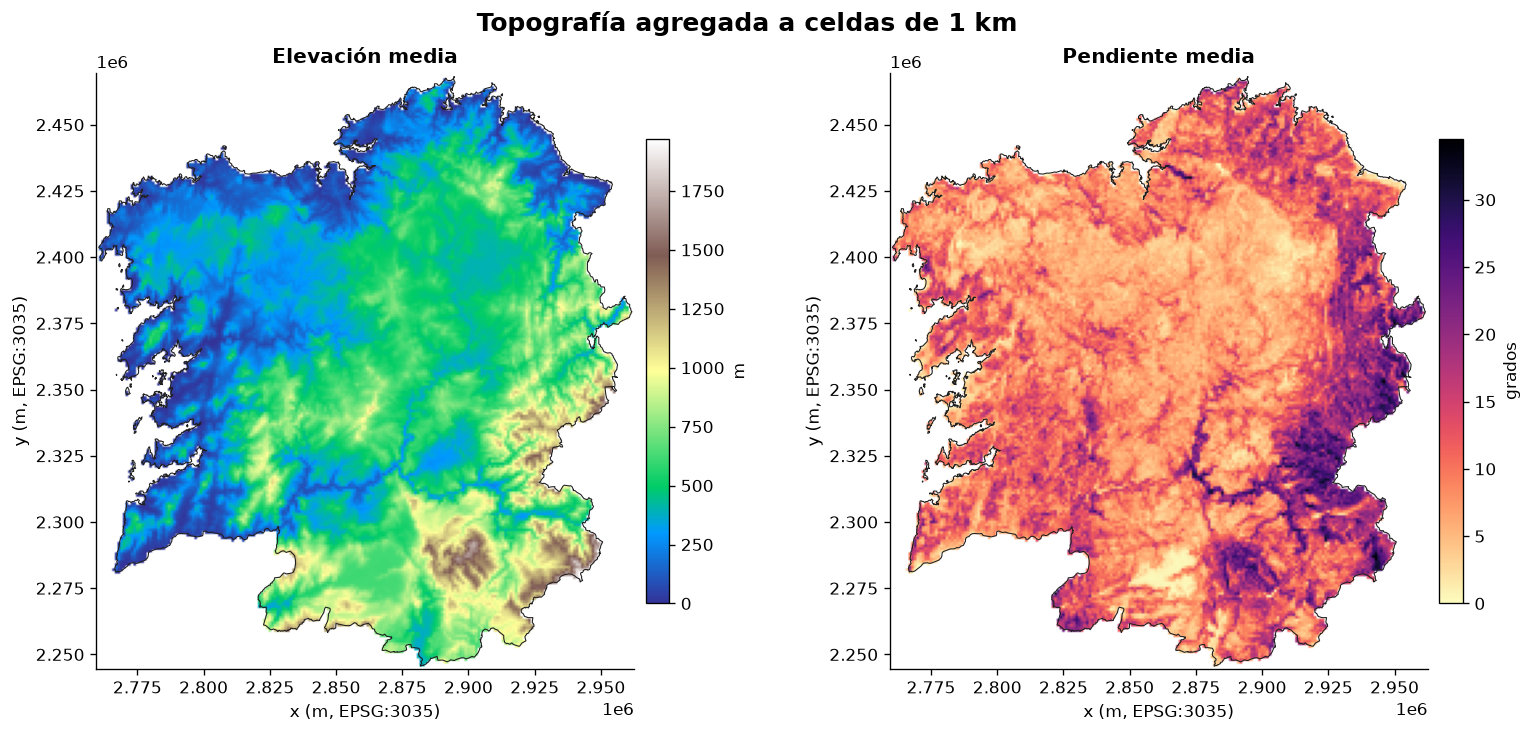

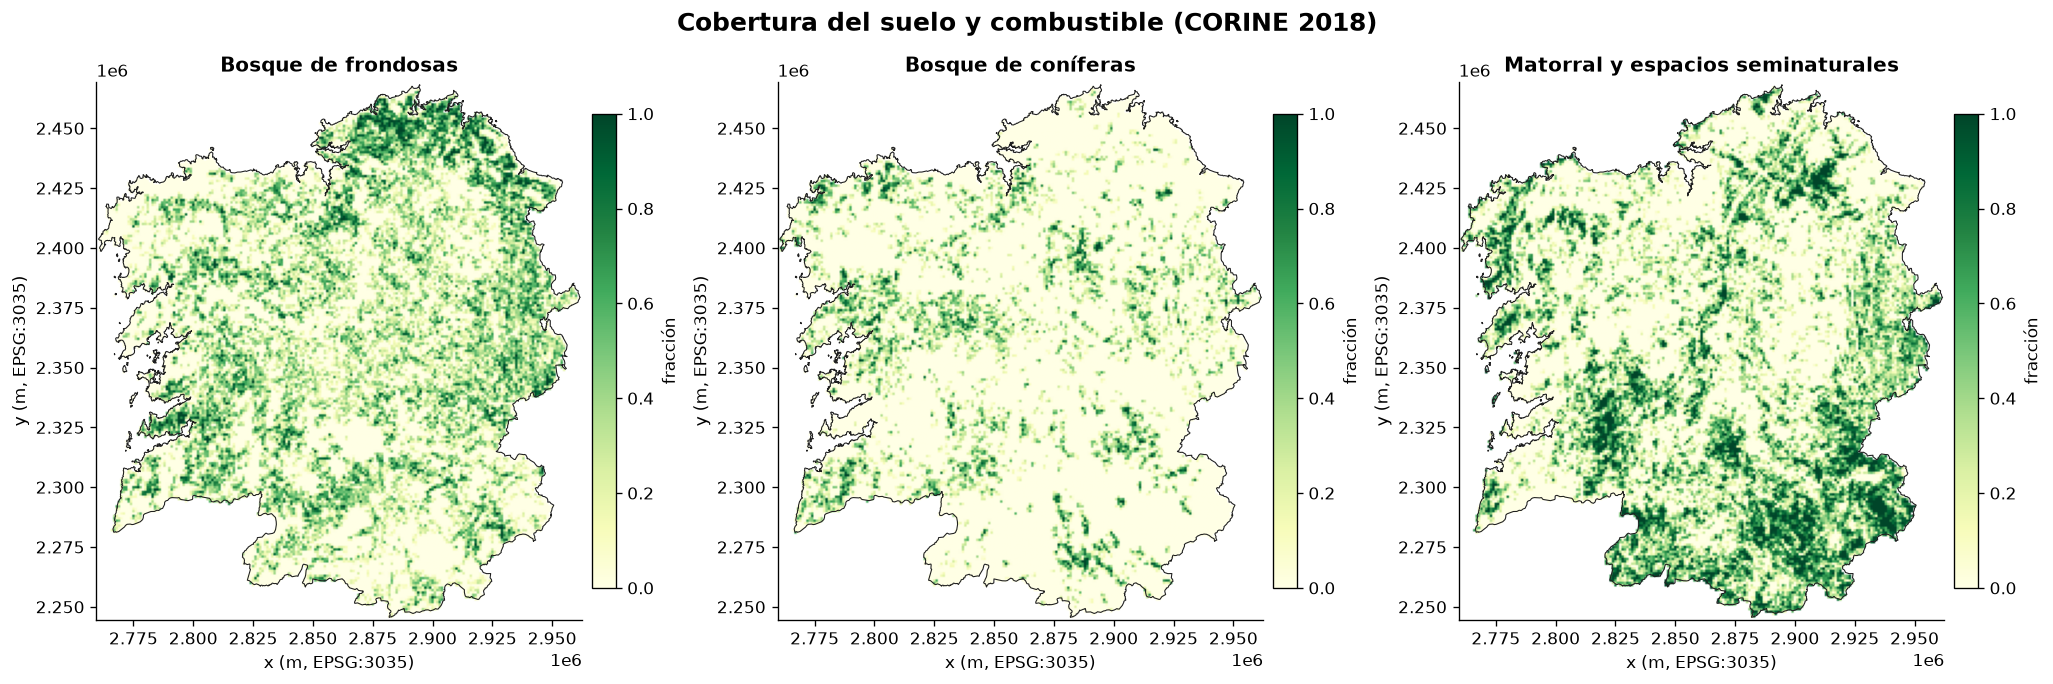

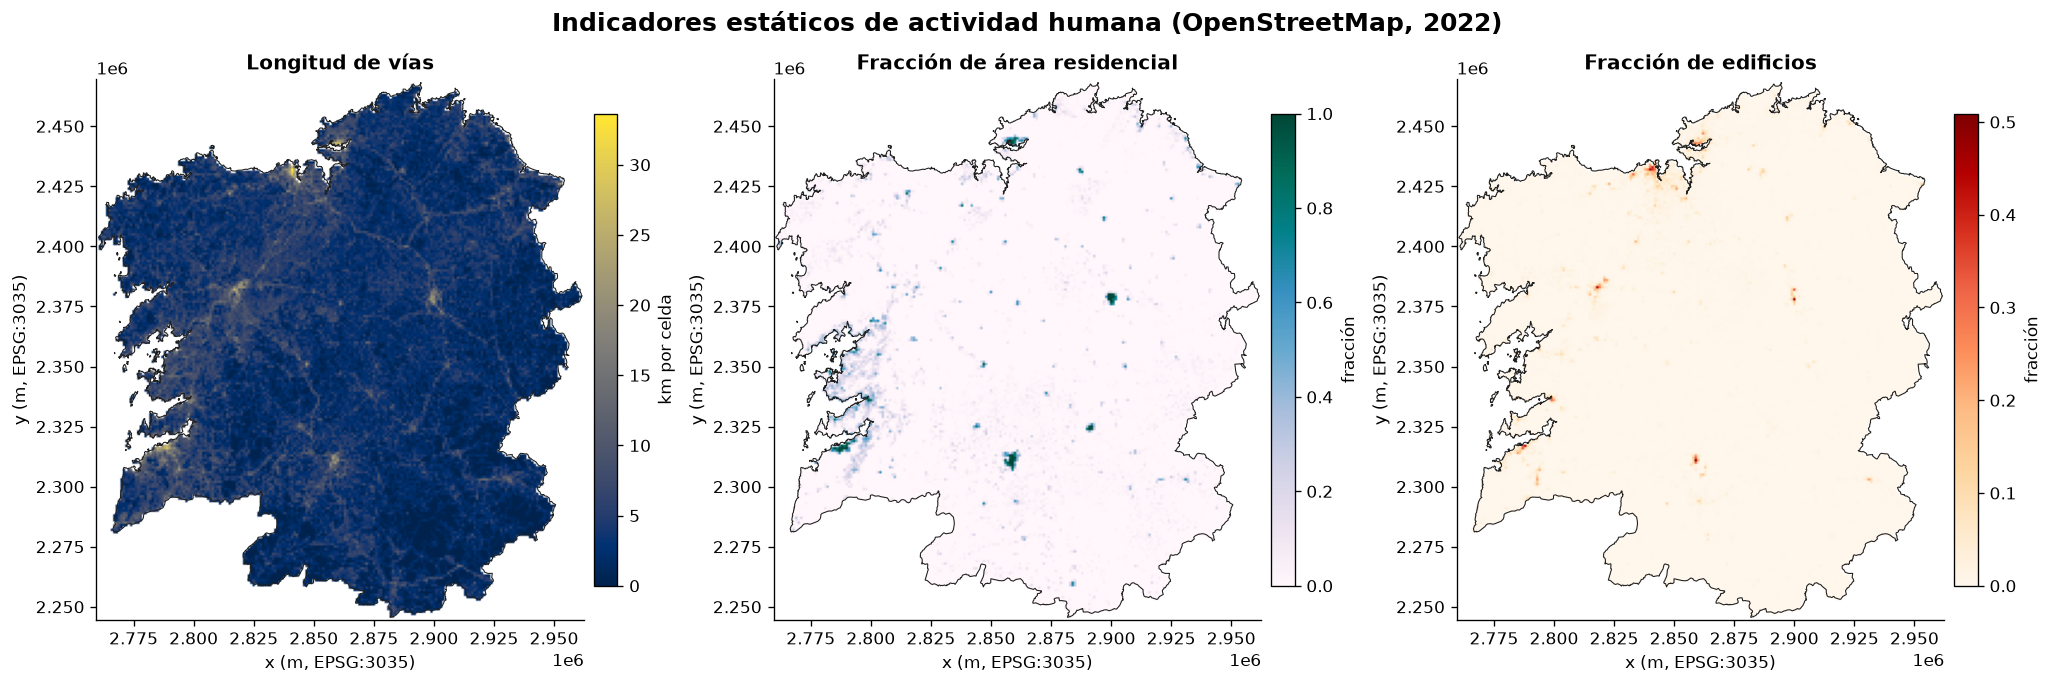

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
map_layer(axes[0], cube['elevation_mean'].values, 'Elevación media', 'terrain', 'm')
map_layer(axes[1], cube['slope_mean'].values, 'Pendiente media', 'magma_r', 'grados')
fig.suptitle('Topografía agregada a celdas de 1 km', fontsize=15, fontweight='bold')
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.6), constrained_layout=True)
for ax, variable, title in zip(axes, ['broadleaf_forest', 'coniferous_forest', 'scrub'],
                               ['Bosque de frondosas', 'Bosque de coníferas', 'Matorral y espacios seminaturales']):
    map_layer(ax, cube[variable].values, title, 'YlGn', 'fracción', 0, 1)
fig.suptitle('Cobertura del suelo y combustible (CORINE 2018)', fontsize=15, fontweight='bold')
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.6), constrained_layout=True)
for ax, variable, title, cmap, unit in zip(axes,
    ['road_length_km', 'residential_area_fraction', 'building_area_fraction'],
    ['Longitud de vías', 'Fracción de área residencial', 'Fracción de edificios'],
    ['cividis', 'PuBuGn', 'OrRd'], ['km por celda', 'fracción', 'fracción']):
    map_layer(ax, cube[variable].values, title, cmap, unit)
fig.suptitle('Indicadores estáticos de actividad humana (OpenStreetMap, 2022)', fontsize=15, fontweight='bold')
plt.show()
plt.close(fig)

## 3. Capas dinámicas: condiciones meteorológicas y objetivo EGIF

Las variables de ERA5-Land se agregan diariamente y se interpolan a la rejilla de 1 km. Se
escoge automáticamente el día con más celdas-día positivas EGIF para mostrar conjuntamente la
meteorología y las igniciones observadas. Esta figura permite explicar que el objetivo y las
variables meteorológicas comparten una referencia espacial y temporal.


Día seleccionado: 2022-07-14 (55 celdas con ignición EGIF)


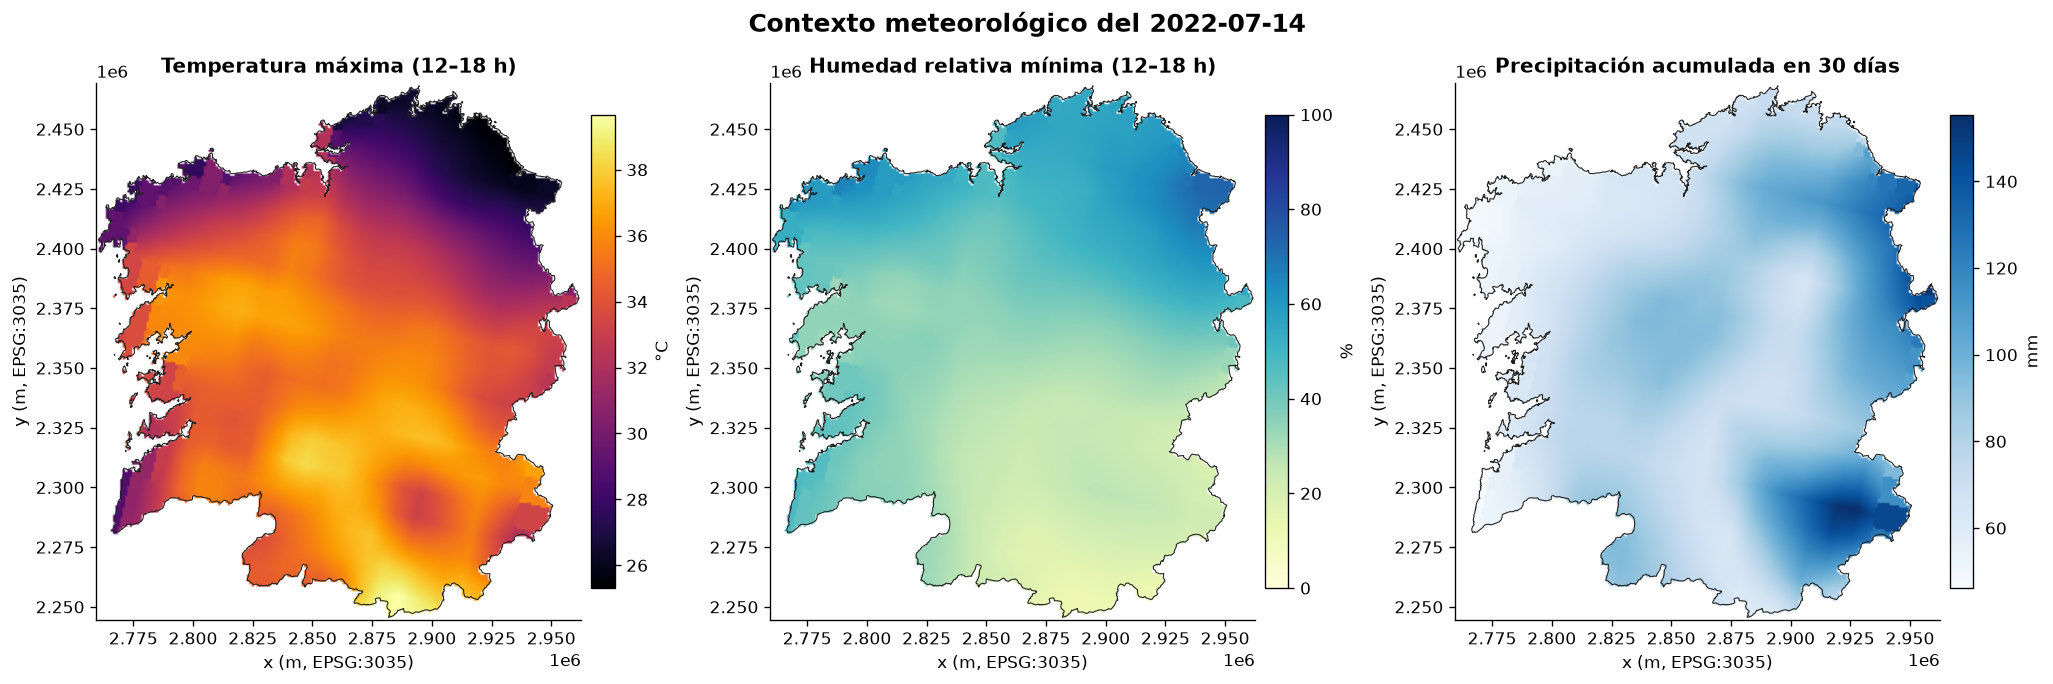

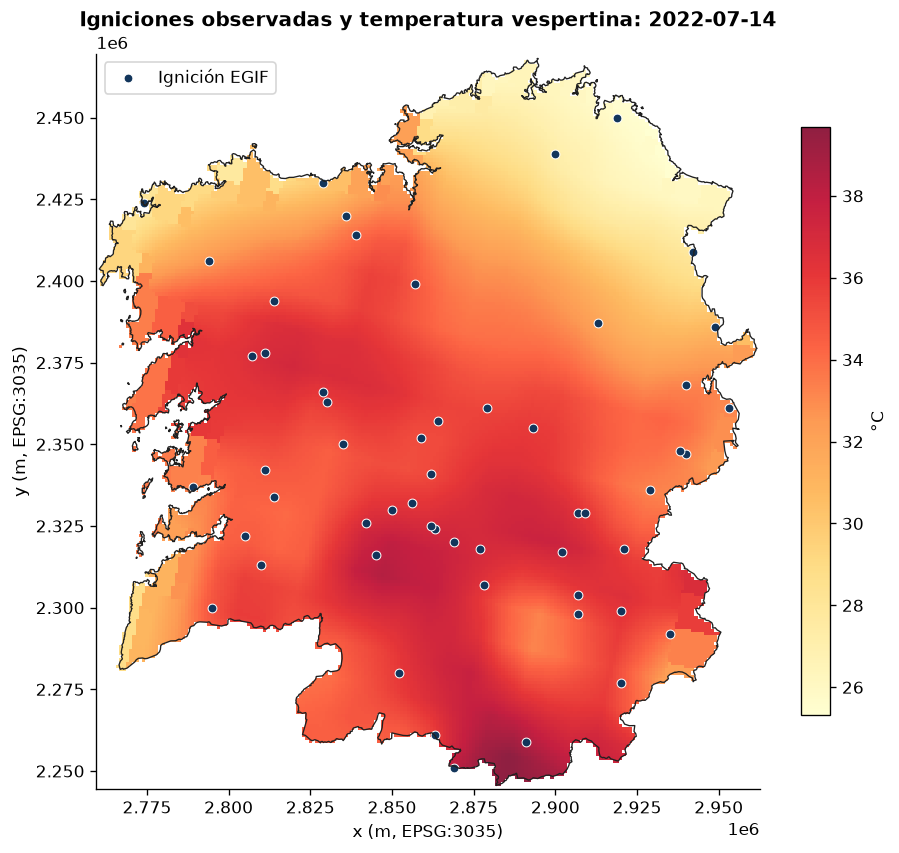

In [16]:
# Jornada representativa de actividad elevada (55 celdas con ignición EGIF).
# Se fija para que la figura sea reproducible y no necesite recorrer todo el NetCDF.
event_date = pd.Timestamp('2022-07-14')
n_ignitions = int(np.nansum(cube['target_ignicion'].sel(time=event_date).values))
print(f'Día seleccionado: {event_date.date()} ({n_ignitions} celdas con ignición EGIF)')

fig, axes = plt.subplots(1, 3, figsize=(17, 5.6), constrained_layout=True)
map_layer(axes[0], cube['temperature_max_12_18h'].sel(time=event_date).values,
          'Temperatura máxima (12–18 h)', 'inferno', '°C')
map_layer(axes[1], cube['relative_humidity_min_12_18h'].sel(time=event_date).values,
          'Humedad relativa mínima (12–18 h)', 'YlGnBu', '%', 0, 100)
map_layer(axes[2], cube['precipitation_sum_30d'].sel(time=event_date).values,
          'Precipitación acumulada en 30 días', 'Blues', 'mm')
fig.suptitle(f'Contexto meteorológico del {event_date.date()}', fontsize=15, fontweight='bold')
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
risk_background = np.ma.masked_where(
    ~active, cube['temperature_max_12_18h'].sel(time=event_date).values
)
image = ax.imshow(risk_background, origin='lower', extent=extent, cmap='YlOrRd', alpha=.88)
fires = cube['target_ignicion'].sel(time=event_date).values == 1
rows, cols = np.where(fires)
ax.scatter(cube.x.values[cols], cube.y.values[rows], s=28, color='#12355b',
           edgecolor='white', linewidth=.6, label='Ignición EGIF')
draw_boundary(ax, color='#202020', linewidth=.8)
ax.set(title=f'Igniciones observadas y temperatura vespertina: {event_date.date()}',
       xlabel='x (m, EPSG:3035)', ylabel='y (m, EPSG:3035)')
ax.legend(loc='upper left', frameon=True)
plt.colorbar(image, ax=ax, shrink=.8, label='°C')
plt.show()
plt.close(fig)


## 4. Eje temporal, familias de variables y arquitectura

Los gráficos siguientes muestran la evolución temporal de las igniciones, las familias de
predictores y la transformación clave del proyecto: las fuentes se integran en un cubo
espacial-temporal y se exportan como una tabla de celdas-día para el modelado.


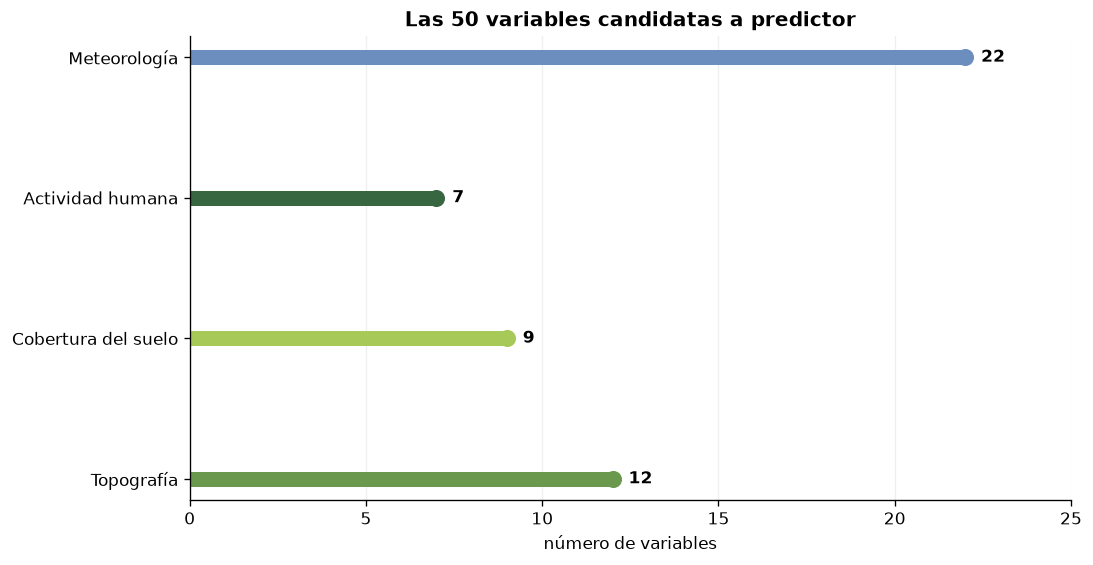

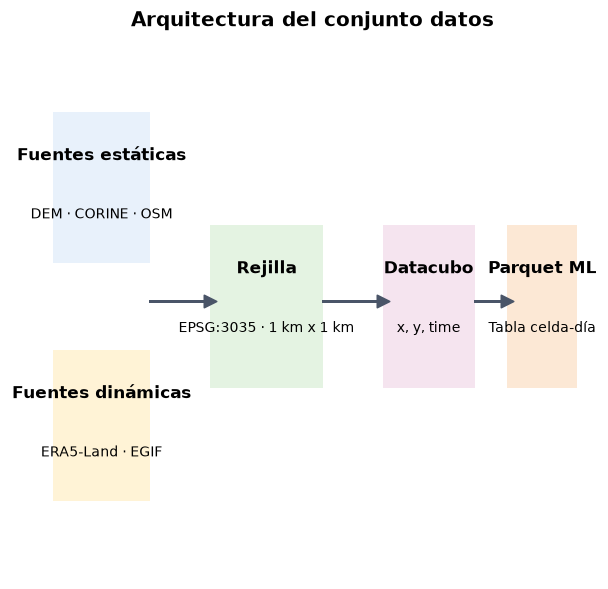

Periodo: 2016-01-01 → 2023-12-31
Filas Parquet: 86,494,122
Predictores publicados: 50
Identificadores de trazabilidad exportados: fecha, x, y, cell_id, year (no predictivos).


In [22]:
groups = {'Topografía': 12, 'Cobertura del suelo': 9, 'Actividad humana': 7, 'Meteorología': 22}
names, values = list(groups), np.array(list(groups.values()))
fig, ax = plt.subplots(figsize=(9, 4.6), constrained_layout=True)
for position, (name, value, color) in enumerate(zip(names, values, ['#6a994e', '#a7c957', '#386641', '#6c8ebf'])):
    ax.plot([0, value], [position, position], color=color, linewidth=9, solid_capstyle='round')
    ax.scatter(value, position, color=color, s=85, zorder=3)
    ax.text(value + .45, position, str(value), va='center', fontweight='bold')
ax.set(title='Las 50 variables candidatas a predictor', xlabel='número de variables', xlim=(0, 25), yticks=range(len(names)), yticklabels=names)
ax.grid(axis='x', alpha=.2)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(14, 4.8), constrained_layout=True)
canvas = np.ones((100, 100, 3))
colors = np.array([[232, 241, 251], [255, 243, 214], [228, 243, 226], [245, 228, 239], [252, 232, 213]]) / 255
canvas[58:86, 2:20] = colors[0]; canvas[14:42, 2:20] = colors[1]
canvas[35:65, 31:52] = colors[2]; canvas[35:65, 63:80] = colors[3]; canvas[35:65, 86:99] = colors[4]
ax.imshow(canvas, extent=(0, 1, 0, 1), interpolation='nearest', origin='lower')
labels = [(0.11, .72, 'Fuentes estáticas', 'DEM · CORINE · OSM'), (0.11, .28, 'Fuentes dinámicas', 'ERA5-Land · EGIF'), (0.415, .51, 'Rejilla', 'EPSG:3035 · 1 km x 1 km'), (0.715, .51, 'Datacubo', 'x, y, time'), (0.925, .51, 'Parquet ML', 'Tabla celda-día')]
for x_pos, y_pos, title, subtitle in labels:
    ax.text(x_pos, y_pos + .06, title, ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(x_pos, y_pos - .05, subtitle, ha='center', va='center', fontsize=8.5)
for x0, x1 in [(0.20, .31), (.52, .63), (.80, .86)]:
    ax.plot([x0, x1], [.51, .51], color='#4a5568', linewidth=1.8)
    ax.scatter(x1, .51, marker='>', color='#4a5568', s=55, zorder=3)
ax.set(title='Arquitectura del conjunto datos', xlim=(0, 1), ylim=(0, 1))
ax.set_axis_off()
plt.show()
plt.close(fig)

print(f"Periodo: {str(cube.time.min().values)[:10]} → {str(cube.time.max().values)[:10]}")
print(f"Filas Parquet: {sum(metadata['annual_files'].values()):,}")
print(f"Predictores publicados: {len(metadata['predictor_columns'])}")
print('Identificadores de trazabilidad exportados: fecha, x, y, cell_id, year (no predictivos).')

## 5. Escala anual y exportación tabular

Esta figura es especialmente útil para la memoria porque resume, con datos reales, la diferencia
entre el producto espacial-temporal y los Parquet anuales que alimentan el entrenamiento. Las
filas de Parquet corresponden a combinaciones de una celda activa y un día.


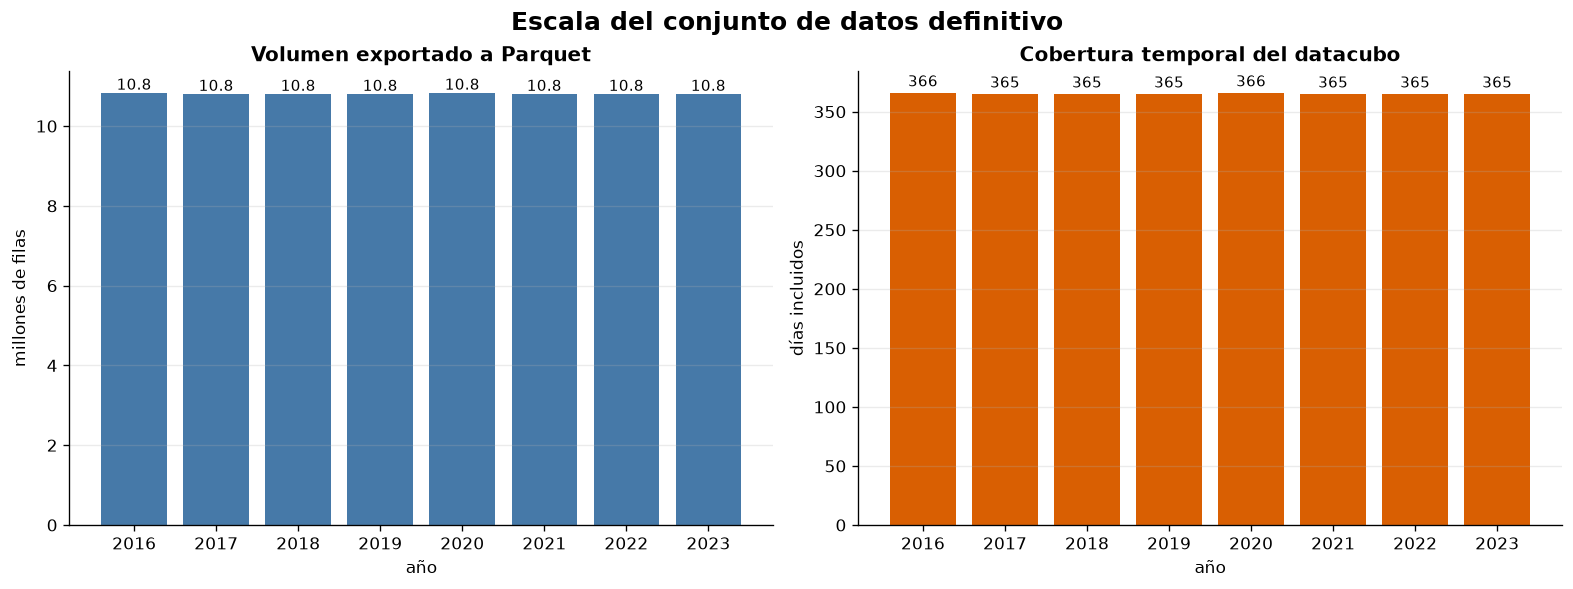

Periodo: 2016-01-01 → 2023-12-31 (2,922 días)
Filas Parquet: 86,494,122
Predictores publicados: 50
Identificadores de trazabilidad: fecha, x, y, cell_id y year (no predictivos).


In [12]:
years = np.array(sorted(int(year) for year in metadata['annual_files']))
rows_by_year = pd.Series(
    {int(year): int(rows) for year, rows in metadata['annual_files'].items()}
).reindex(years)
days_by_year = rows_by_year / int(active.sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

axes[0].plot(years, rows_by_year / 1e6, color='#4679a8', linewidth=2.5, marker='o', markersize=7)
axes[0].set(title='Volumen exportado a Parquet', xlabel='año', ylabel='millones de filas')
axes[0].set_xticks(years)
axes[0].grid(axis='y', alpha=.25)
for year, value in zip(years, rows_by_year / 1e6):
    axes[0].text(year, value + .08, f'{value:.1f}', ha='center', fontsize=9)

axes[1].plot(years, days_by_year, color='#d95f02', linewidth=2.5, marker='o', markersize=7)
axes[1].set(title='Cobertura temporal del datacubo', xlabel='año', ylabel='días incluidos')
axes[1].set_xticks(years)
axes[1].grid(axis='y', alpha=.25)
offset = max(days_by_year) * .015
for year, value in zip(years, days_by_year):
    axes[1].text(year, value + offset, f'{int(value):,}', ha='center', fontsize=9)

fig.suptitle('Escala del conjunto de datos definitivo', fontsize=15, fontweight='bold')
plt.show()
plt.close(fig)

print(f"Periodo: {pd.Timestamp(cube.time.min().item()).date()} → "
      f"{pd.Timestamp(cube.time.max().item()).date()} ({cube.sizes['time']:,} días)")
print(f"Filas Parquet: {sum(metadata['annual_files'].values()):,}")
print(f"Predictores publicados: {len(metadata['predictor_columns'])}")
print('Identificadores de trazabilidad: fecha, x, y, cell_id y year (no predictivos).')


## Selección recomendada para la memoria

Con un límite de 20 páginas no conviene insertar todas las figuras. La combinación más útil es:

1. **Rejilla y máscara de Galicia**, al final del apartado 3.1.
2. **Arquitectura del datacubo y Parquet**, después de las familias de variables en el apartado 3.3.

La nueva figura de escala anual puede sustituir a la primera si se quiere reforzar el volumen y la
continuidad temporal del conjunto. Las figuras de topografía, combustible, actividad humana y
evento meteorológico se conservan como apoyo para anexos o la presentación oral.
